# MoE Dual-Branch Encoder — UMAP + KMeans Visualizer

Follows the same 3-panel layout for each head:
- **Panel 1** — coloured by Subject ID
- **Panel 2** — coloured by KMeans cluster (with ARI / NMI / Silhouette)
- **Panel 3** — coloured by Stress label

In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import umap
from torch.utils.data import DataLoader, Subset
import pickle
from models.net.moe_encoder import MoEDualBranchEncoder
REPO_ROOT = "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning"
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
from sklearn.manifold import TSNE

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
print("Imports OK")

Imports OK


## 1. Configuration  ← edit here

In [2]:
# ── Checkpoint ────────────────────────────────────────────────────────────────
CHECKPOINT = ""

# ── Dataset ───────────────────────────────────────────────────────────────────
DATASET_NAME = "WESADDataset"      # WESADDataset | SWELLDataset | StressIDDataset
DATASET_PATH = "/home/s223149341/SSL-invariance-Subject_Project_model/data/WESAD/wesad_10_05_no_standardize"

ALL_DEFAULTS = {
    "WESADModel": {
        "model_path": "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/dual_branch_flatten/moe_dual_branch_WESADDataset_0/pretrain/encoder_best_.pt",
        "dataset_name": "WESADDataset",
        "dataset_path": "/home/s223149341/SSL-invariance-Subject_Project_model/data/WESAD/wesad_10_05_no_standardize",
    },
    "SWELLModel": {
        "model_path": "/home/s223149341/SSL-invariance-Subject_Project_model/subject_aware_contrastive_learning/save/dual_branch_flatten/moe_dual_branch_SWELLDataset_0/pretrain/encoder_best_.pt",
        "dataset_name": "SWELLDataset",
        "dataset_path": "/home/s223149341/SSL-invariance-Subject_Project_model/data/SWELL/SWELL_1280_320_3label",
    },
}


# ── Encoder architecture (must match the checkpoint) ─────────────────────────
INPUT_DIM         = 1280
OUTPUT_DIM        = 64
PROJECTION_OUTPUT = 32
KERNEL_SIZE       = 10
STRIDE            = 1
DROPOUT_PROB      = 0.0

# ── UMAP ──────────────────────────────────────────────────────────────────────
N_NEIGHBORS  = 15
MIN_DIST     = 0.1
RANDOM_STATE = 42

# ── KMeans ────────────────────────────────────────────────────────────────────
# Set to None to auto-set k = number of unique subjects
KMEANS_K = None

# ── Misc ──────────────────────────────────────────────────────────────────────
BATCH_SIZE = 256
OUTPUT_DIR = "./umap_plots"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
from datasets.wesad_dataset import WESADDataset
from datasets.swell_stressid_dataset import SWELL_STRESSID_Dataset

#Get the dataset from the config file
def get_wesad_dataset(config):
    dat_cfg = config['pretrain_args']['dataset_args']['train_dataset_args']
    dat_cfg.pop('data_name', None)
    dat_cfg["dataset_path"] = "/home/s223149341/SSL-invariance-Subject_Project_model/data/WESAD/wesad_10_05_no_standardize"
    print("Dataset config:", dat_cfg)
    dataset =  WESADDataset(**dat_cfg)
    return dataset
    

# 2 Metrics Computation

In [4]:
# Uniformity
def calculate_uniformity(embeddings, temperature=2.0):
    # Normalize embeddings
    norm_embeddings = F.normalize(embeddings, dim=1)
    # Compute pairwise distances
    sq_pdist = torch.pdist(norm_embeddings, p=2).pow(2)
    return sq_pdist.mul(-temperature).exp().mean().log()

# Alignment
def calculate_alignment(first_emebedding, second_embeddings, alpha=2.0):
    return (first_emebedding - second_embeddings).norm(dim=1).pow(alpha).mean()


def calculate_label_separability(embeddings, labels):
    norm_embedding = F.normalize(embeddings, dim=1)
    distance = torch.cdist(norm_embedding, norm_embedding, p=2)  # NxN
    same_label_mask = labels.unsqueeze(1) == labels.unsqueeze(0)
    different_label_mask = ~same_label_mask

    # avoid self-comparison (diagonal)
    eye = torch.eye(labels.size(0), dtype=torch.bool, device=labels.device)
    same_label_mask = same_label_mask & ~eye

    same_dist = distance[same_label_mask]
    different_dist = distance[different_label_mask]

    score = same_dist.mean() / (different_dist.mean() + 1e-8)
    return score.item()


# Subject Separability
def calculate_subject_separability(embeddings, subjects):
    norm_embedding = F.normalize(embeddings, dim=1)

    distance = torch.cdist(norm_embedding, norm_embedding, p=2)

    same_subject_mask = subjects.unsqueeze(1) == subjects.unsqueeze(0)
    different_subject_mask = ~same_subject_mask

    eye = torch.eye(subjects.size(0), dtype=torch.bool, device=subjects.device)
    same_subject_mask = same_subject_mask & ~eye

    same_dist = distance[same_subject_mask]
    different_dist = distance[different_subject_mask]

    score = same_dist.mean() / (different_dist.mean() + 1e-8)
    return score.item()



## 2. Helper Functions

In [5]:
def cmap_colors(ids, cmap_name="tab20"):
    """Assign one colour per unique id.  Returns colours array, unique ids, cmap."""
    unique       = np.unique(ids)
    cmap         = cm.get_cmap(cmap_name, len(unique))
    id_to_color  = {uid: cmap(i) for i, uid in enumerate(unique)}
    return np.array([id_to_color[i] for i in ids]), unique, cmap

## 3. Load Encoder

In [6]:

def create_encoder_from_checkpoint(checkpoint_path):
    device  = torch.device(DEVICE)
    encoder = MoEDualBranchEncoder(
        input_dim         = INPUT_DIM,
        dropout_prob      = DROPOUT_PROB,
        kernel_size       = KERNEL_SIZE,
        stride            = STRIDE,
        output_dim        = OUTPUT_DIM,
        projection_output = PROJECTION_OUTPUT,
    ).to(device)

    ckpt   = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    sd     = ckpt.get("state_dict", ckpt)
    enc_sd = {}
    for k, v in sd.items():
        k = k.replace("module.", "", 1)
        for prefix in ("encoder_q.", "encoder.", "encoder_i."):
            if k.startswith(prefix):
                k = k[len(prefix):]
                break
        enc_sd[k] = v

    msg = encoder.load_state_dict(enc_sd, strict=False)
    if msg.missing_keys:
        print("Missing keys:", msg.missing_keys)
    encoder.eval()
    print("Encoder loaded OK")
    return encoder

def create_random_encoder():
    """Return a MoEDualBranchEncoder with random (untrained) weights — used as baseline."""
    device  = torch.device(DEVICE)
    encoder = MoEDualBranchEncoder(
        input_dim         = INPUT_DIM,
        dropout_prob      = DROPOUT_PROB,
        kernel_size       = KERNEL_SIZE,
        stride            = STRIDE,
        output_dim        = OUTPUT_DIM,
        projection_output = PROJECTION_OUTPUT,
    ).to(device)
    encoder.eval()
    print("Random-init encoder created (no weights loaded).")
    return encoder


In [7]:
for dataset in ALL_DEFAULTS:
    ckpt = ALL_DEFAULTS[dataset]["model_path"]
    ALL_DEFAULTS[dataset]["encoder"] = create_encoder_from_checkpoint(ckpt)

Encoder loaded OK
Encoder loaded OK


## 4. Build DataLoader

In [8]:
from datasets.wesad_dataset import WESADDataset
from datasets.swell_stressid_dataset import SWELL_STRESSID_Dataset

def create_dataloader(data_path):
    ds_args = dict(
        dataset_path              = data_path,
        include_labels            = True,
        sub_sample_frac           = None,
        data_views                = None,
        transform_dict_core       = None,
        transform_dict_artifact   = None,
        transform_global_core     = None,
        transform_global_artifact = None,
    )

    if   DATASET_NAME == "WESADDataset":                    ds = WESADDataset(**ds_args)
    elif DATASET_NAME in ("SWELLDataset","StressIDDataset"): ds = SWELL_STRESSID_Dataset(**ds_args)
    else: raise ValueError(DATASET_NAME)

    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, drop_last=False)
    print(f"Dataset size: {len(ds)}  |  Batches: {len(loader)}")
    return loader


for dataset in ALL_DEFAULTS:
    data_path = ALL_DEFAULTS[dataset]["dataset_path"]
    ALL_DEFAULTS[dataset]["dataloader"] = create_dataloader(data_path)

100%|██████████| 15/15 [00:03<00:00,  4.91it/s]


sub sample frac is None
Sampled 65428 examples

=== Label Statistics ===
Label 0 count: 45791 = 69.99%
Label 1 count: 19637 = 30.01%

=== Subject Statistics ===
Total subjects: 15

=== Samples Per Subject ===
  Subject S10: 4496 samples (6.9% of total)
  Subject S11: 4398 samples (6.7% of total)
  Subject S13: 4393 samples (6.7% of total)
  Subject S14: 4396 samples (6.7% of total)
  Subject S15: 4408 samples (6.7% of total)
  Subject S16: 4384 samples (6.7% of total)
  Subject S17: 4494 samples (6.9% of total)
  Subject S2: 4184 samples (6.4% of total)
  Subject S3: 4251 samples (6.5% of total)
  Subject S4: 4272 samples (6.5% of total)
  Subject S5: 4375 samples (6.7% of total)
  Subject S6: 4345 samples (6.6% of total)
  Subject S7: 4337 samples (6.6% of total)
  Subject S8: 4359 samples (6.7% of total)
  Subject S9: 4336 samples (6.6% of total)
Dataset size: 65428  |  Batches: 256


100%|██████████| 25/25 [00:12<00:00,  2.01it/s]


sub sample frac is None
Sampled 51714 examples

=== Label Statistics ===
Label 0 count: 33487 = 64.75%
Label 1 count: 18227 = 35.25%

=== Subject Statistics ===
Total subjects: 25

=== Samples Per Subject ===
  Subject s10_phsyio.pkl: 2335 samples (4.5% of total)
  Subject s11_phsyio.pkl: 784 samples (1.5% of total)
  Subject s12_phsyio.pkl: 2577 samples (5.0% of total)
  Subject s13_phsyio.pkl: 2257 samples (4.4% of total)
  Subject s14_phsyio.pkl: 2567 samples (5.0% of total)
  Subject s15_phsyio.pkl: 2210 samples (4.3% of total)
  Subject s16_phsyio.pkl: 2579 samples (5.0% of total)
  Subject s17_phsyio.pkl: 2578 samples (5.0% of total)
  Subject s18_phsyio.pkl: 2338 samples (4.5% of total)
  Subject s19_phsyio.pkl: 2379 samples (4.6% of total)
  Subject s1_phsyio.pkl: 2563 samples (5.0% of total)
  Subject s20_phsyio.pkl: 1644 samples (3.2% of total)
  Subject s21_phsyio.pkl: 2026 samples (3.9% of total)
  Subject s22_phsyio.pkl: 1611 samples (3.1% of total)
  Subject s23_phsyio.pk

## 5. Extract Embeddings

In [9]:
def create_embeddings(encoder, loader):
    z_inv_list, z_spec_list, h_out_list, h_list = [], [], [], []
    subj_list, label_list = [], []

    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(DEVICE).float()
            h, h_out,_, z_inv, z_spec = encoder(x, return_embeddings=True)

            z_inv_list.append(z_inv.cpu().numpy())
            h_list.append(h.cpu().numpy())
            z_spec_list.append(z_spec.cpu().numpy())
            h_out_list.append(h_out.cpu().numpy())

            subj = batch.get("subject_id_int", None)
            subj_list.append(subj.cpu().numpy())

            lbl = batch.get("y", None)
            label_list.append(lbl.cpu().numpy().flatten().astype(int))

    Z_INV  = np.vstack(z_inv_list)
    Z_SPEC = np.vstack(z_spec_list)
    H_OUT  = np.vstack(h_out_list)
    H      = np.vstack(h_list) 
    SUBJ   = np.concatenate(subj_list)
    LABELS = np.concatenate(label_list)

    print(f"z_inv  : {Z_INV.shape}")
    print(f"z_spec : {Z_SPEC.shape}")
    print(f"h_out  : {H_OUT.shape}")
    print(f"Subjects : {np.unique(SUBJ)}")
    print(f"Labels   : {np.unique(LABELS)}")

    return {"Z_INV": Z_INV, "Z_SPEC": Z_SPEC, "H_OUT": H_OUT, "H": H, "SUBJ": SUBJ, "LABELS": LABELS}


In [14]:
for dataset in ALL_DEFAULTS:
    encoder = ALL_DEFAULTS[dataset]["encoder"]
    loader  = ALL_DEFAULTS[dataset]["dataloader"]
    ALL_DEFAULTS[dataset].update(create_embeddings(encoder, loader))

# ── Random-init baseline: extract embeddings from both heads ─────────────────
print("\n=== Extracting random-init baseline embeddings ===")
for dataset in ALL_DEFAULTS:
    loader         = ALL_DEFAULTS[dataset]["dataloader"]
    rand_encoder   = create_random_encoder()
    rand_embs      = create_embeddings(rand_encoder, loader)
    # Store with a _rand suffix so they don't overwrite trained embeddings
    ALL_DEFAULTS[dataset]["H"]  = rand_embs["H"]
    ALL_DEFAULTS[dataset]["H_OUT"] = rand_embs["H_OUT"]
    print(f"  {dataset}: random z_inv={rand_embs['Z_INV'].shape}, z_spec={rand_embs['Z_SPEC'].shape}")


z_inv  : (65428, 32)
z_spec : (65428, 32)
h_out  : (65428, 64)
Subjects : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Labels   : [0 1]
z_inv  : (51714, 32)
z_spec : (51714, 32)
h_out  : (51714, 64)
Subjects : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Labels   : [0 1]

=== Extracting random-init baseline embeddings ===
Random-init encoder created (no weights loaded).
z_inv  : (65428, 32)
z_spec : (65428, 32)
h_out  : (65428, 64)
Subjects : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Labels   : [0 1]
  WESADModel: random z_inv=(65428, 32), z_spec=(65428, 32)
Random-init encoder created (no weights loaded).
z_inv  : (51714, 32)
z_spec : (51714, 32)
h_out  : (51714, 64)
Subjects : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Labels   : [0 1]
  SWELLModel: random z_inv=(51714, 32), z_spec=(51714, 32)


## 6. UMAP + TSNE for Each Head

In [15]:
run_data = {}

def compute_metrics(embeddings, subjects, labels):
    embeddings = torch.from_numpy(embeddings).float()
    subjects = torch.tensor(subjects)
    labels = torch.tensor(labels)

    uniformity = calculate_uniformity(embeddings).item()
    label_separability = calculate_label_separability(embeddings, labels)
    subject_separability = calculate_subject_separability(embeddings, subjects)

    return {
        "Uniformity": round(uniformity, 3),
        "Label_Separability": round(label_separability, 3),
        "Subject_Separability": round(subject_separability, 3),
    }


def prepare_data(dataset_data):
    results = {}

    for emb, label in [
        (dataset_data["Z_INV"],       "Invariant Head (z_inv)"),
        (dataset_data["Z_SPEC"],      "Subject-Specific Head (z_spec)"),
        (dataset_data["H_OUT"],       "Concat Head (h_out)"),
        (dataset_data["H"],           "Encoder-Only (h)"),
        (dataset_data["H"],  "Random-Init Encoder Only (z_inv_rand)"),
        (dataset_data["H_OUT"], "Random-Init Concat (z_spec_rand)"),
    ]:
        print(f"\nProcessing: {label}")

        # ── UMAP ─────────────────────────────────────────────
        print("  Fitting UMAP …")
        XY_umap = umap.UMAP(
            n_neighbors=N_NEIGHBORS,
            min_dist=MIN_DIST,
            random_state=RANDOM_STATE,
            n_components=2,
        ).fit_transform(emb)

        print(XY_umap.shape)
        print(dataset_data["LABELS"].shape)
        metrics = compute_metrics(
            emb,
            dataset_data["SUBJ"],
            dataset_data["LABELS"]
        )

        print(
            f"  Uniformity={metrics['Uniformity']}  "
            f"Label Sep={metrics['Label_Separability']}  "
            f"Subject Sep={metrics['Subject_Separability']}"
        )

        results[label] = {
            "label": label,
            "UMAP": XY_umap,
            "S": dataset_data["SUBJ"],
            "L": dataset_data["LABELS"]
            if np.any(dataset_data["LABELS"] >= 0)
            else None,
            "metrics": metrics,
        }

    print("\nAll heads processed.")
    return results

In [16]:
for dataset in ALL_DEFAULTS:
    print(f"Processing dataset: {dataset}")
    umap_run = prepare_data(ALL_DEFAULTS[dataset])
    run_data[dataset] = umap_run


Processing dataset: WESADModel

Processing: Invariant Head (z_inv)
  Fitting UMAP …


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(65428, 2)
(65428,)
  Uniformity=-1.807  Label Sep=0.93  Subject Sep=0.649

Processing: Subject-Specific Head (z_spec)
  Fitting UMAP …


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(65428, 2)
(65428,)
  Uniformity=-0.462  Label Sep=0.923  Subject Sep=0.654

Processing: Concat Head (h_out)
  Fitting UMAP …


...

(51714, 2)
(51714,)
  Uniformity=-0.033  Label Sep=1.002  Subject Sep=0.625

Processing: Random-Init Encoder Only (z_inv_rand)
  Fitting UMAP …


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


(51714, 2)
(51714,)
  Uniformity=-0.033  Label Sep=1.002  Subject Sep=0.625

Processing: Random-Init Concat (z_spec_rand)
  Fitting UMAP …


/home/s223149341/miniconda3/envs/pytorch310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(51714, 2)
(51714,)
  Uniformity=-0.041  Label Sep=0.98  Subject Sep=0.533

All heads processed.


## 7. Plot — 3-Panel UMAP per Head

                                                  Uniformity  Label_Separability  Subject_Separability
Dataset    Embedding                                                                                  
WESADModel Invariant Head (z_inv)                     -1.807               0.930                 0.649
           Subject-Specific Head (z_spec)             -0.462               0.923                 0.654
           Concat Head (h_out)                        -0.000               0.697                 0.527
           Encoder-Only (h)                           -0.026               0.756                 0.517
           Random-Init Encoder Only (z_inv_rand)      -0.026               0.756                 0.517
           Random-Init Concat (z_spec_rand)           -0.000               0.697                 0.527
SWELLModel Invariant Head (z_inv)                     -0.913               0.998                 0.448
           Subject-Specific Head (z_spec)             -0.516             

/tmp/ipykernel_2546396/2707302763.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap         = cm.get_cmap(cmap_name, len(unique))


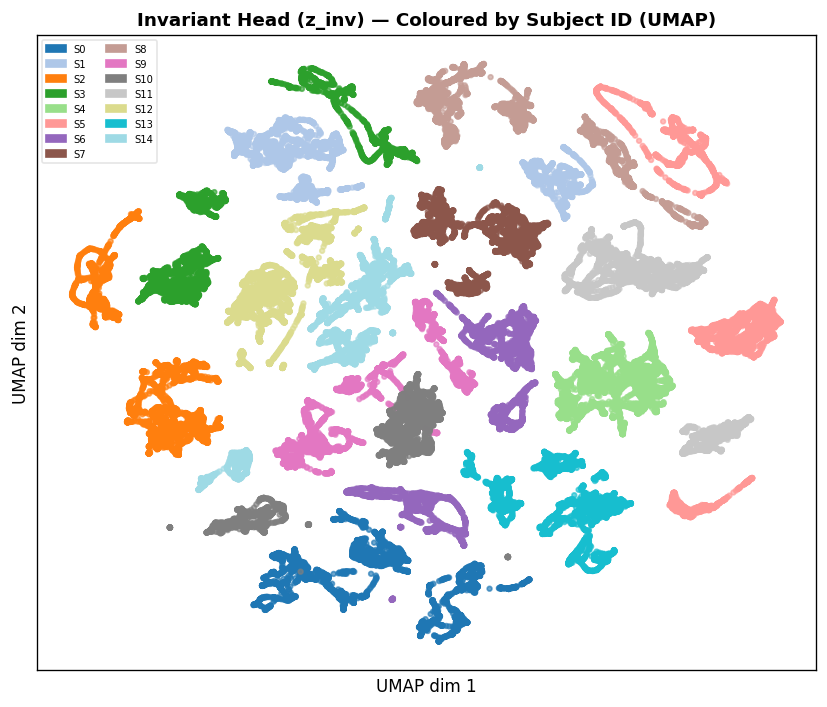

Saved → ./umap_plots/WESADModel_Invariant_Head_z_inv_umap_subjects.png


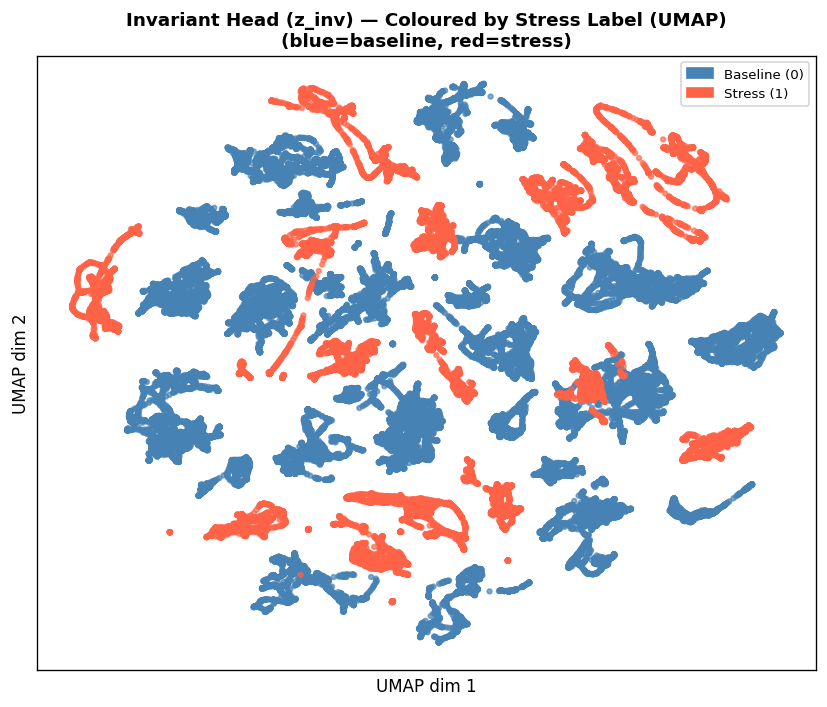

Saved → ./umap_plots/WESADModel_Invariant_Head_z_inv_umap_stress.png


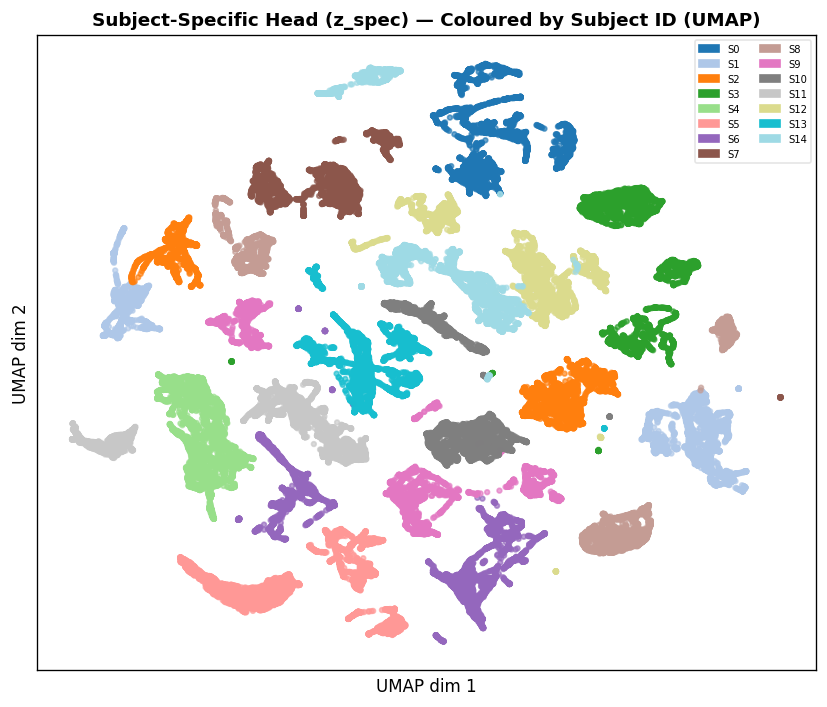

Saved → ./umap_plots/WESADModel_Subject-Specific_Head_z_spec_umap_subjects.png


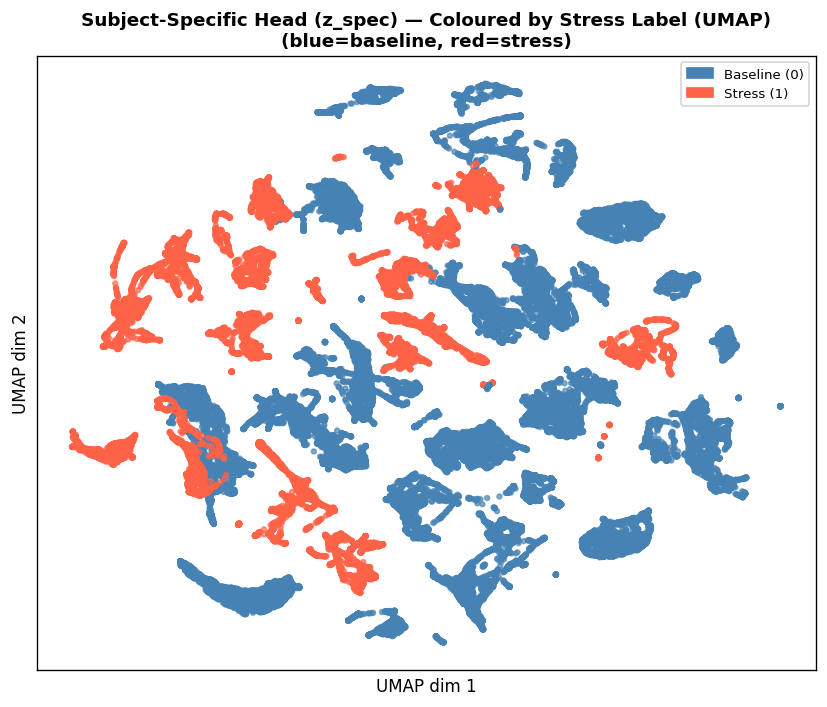

Saved → ./umap_plots/WESADModel_Subject-Specific_Head_z_spec_umap_stress.png


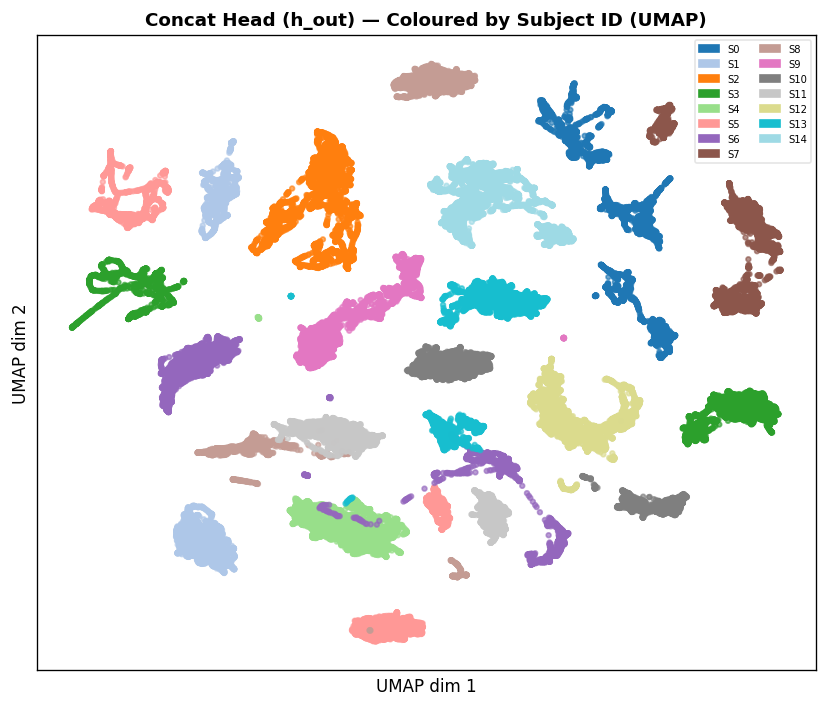

Saved → ./umap_plots/WESADModel_Concat_Head_h_out_umap_subjects.png


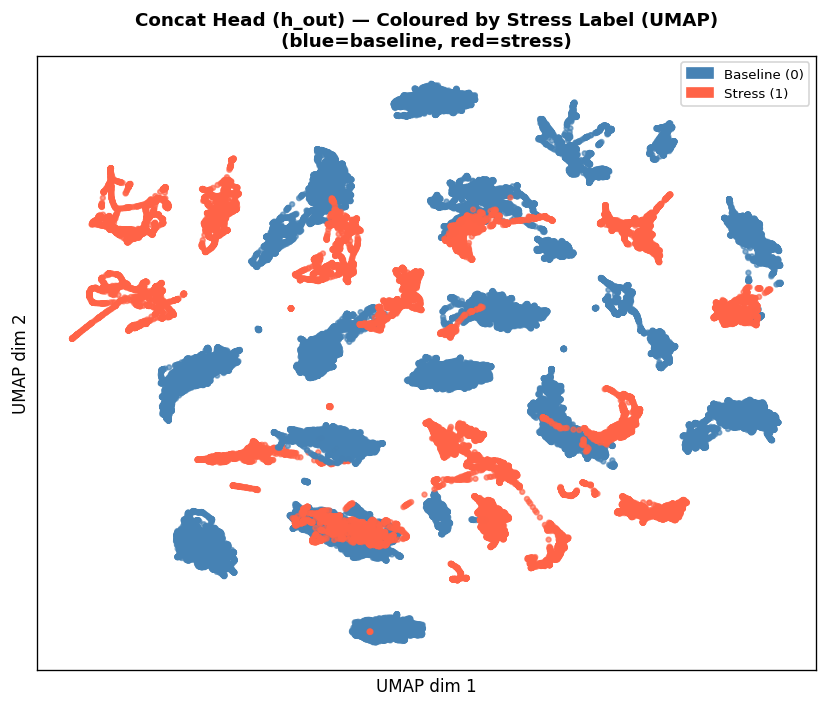

Saved → ./umap_plots/WESADModel_Concat_Head_h_out_umap_stress.png


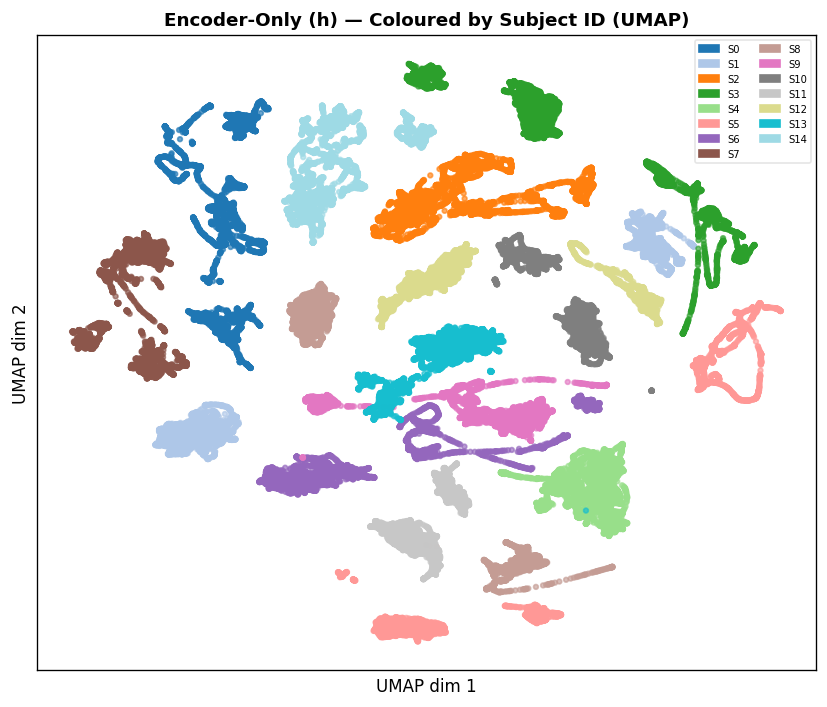

Saved → ./umap_plots/WESADModel_Encoder-Only_h_umap_subjects.png


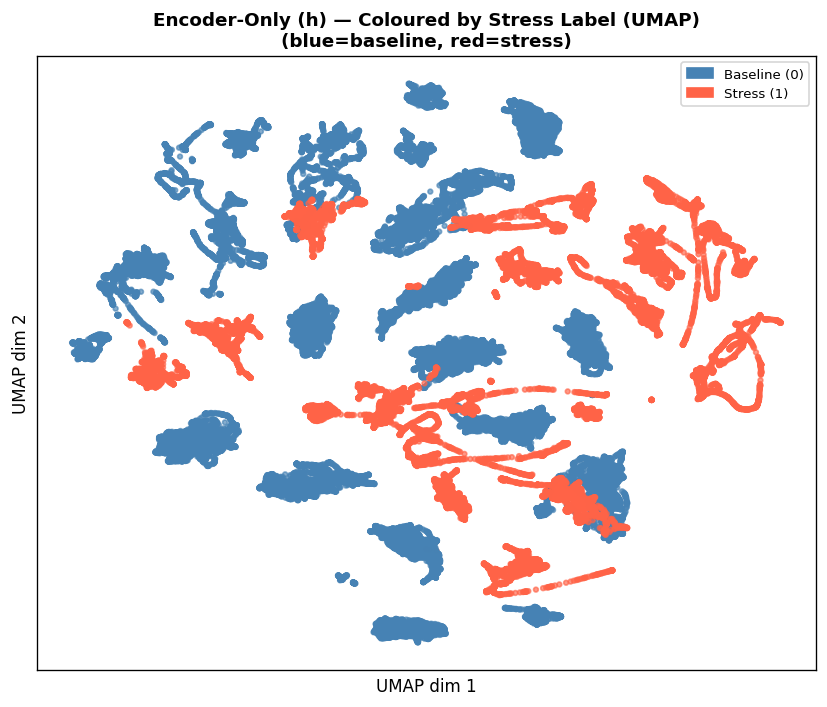

Saved → ./umap_plots/WESADModel_Encoder-Only_h_umap_stress.png


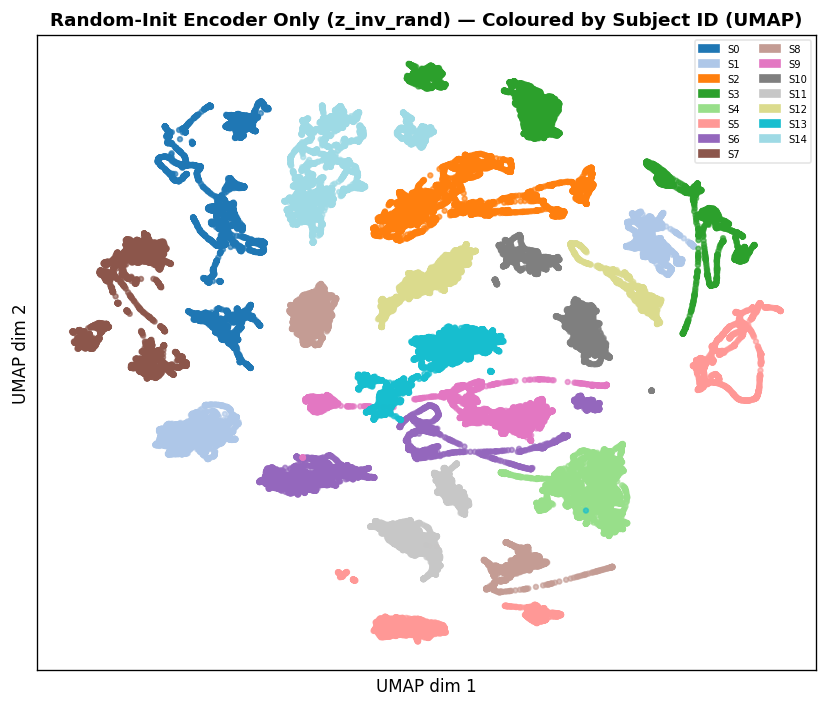

Saved → ./umap_plots/WESADModel_Random-Init_Encoder_Only_z_inv_rand_umap_subjects.png


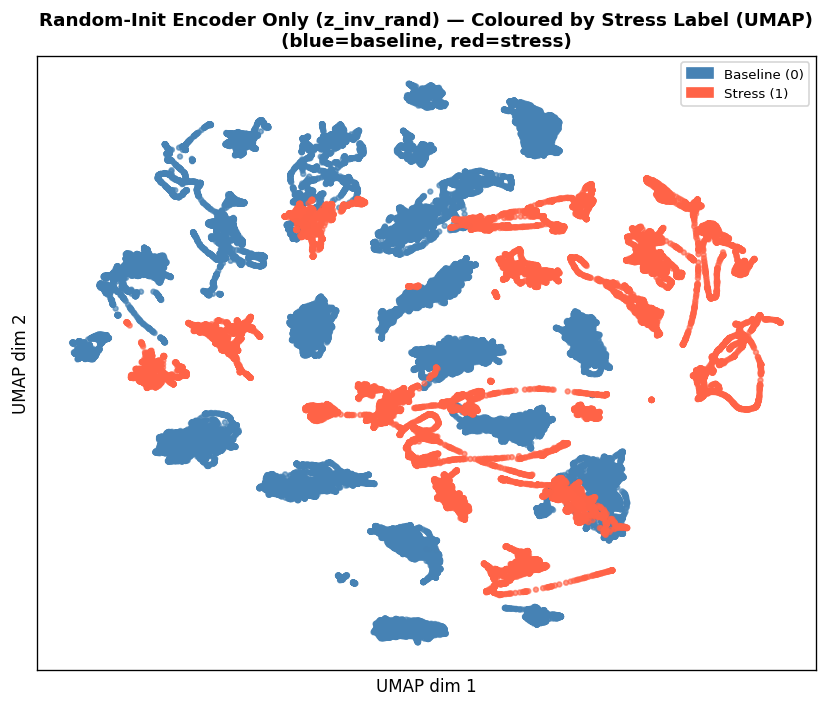

Saved → ./umap_plots/WESADModel_Random-Init_Encoder_Only_z_inv_rand_umap_stress.png


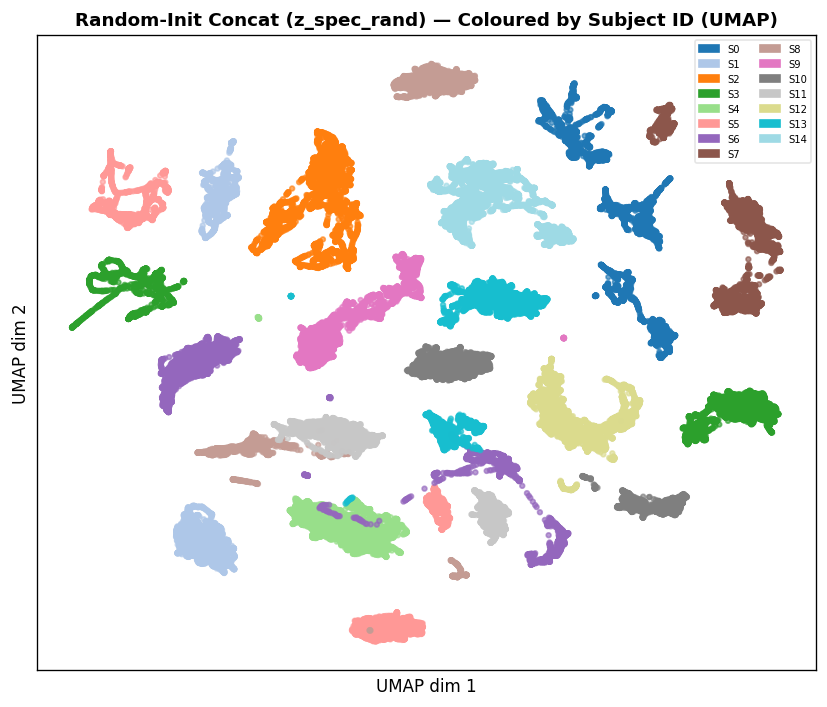

Saved → ./umap_plots/WESADModel_Random-Init_Concat_z_spec_rand_umap_subjects.png


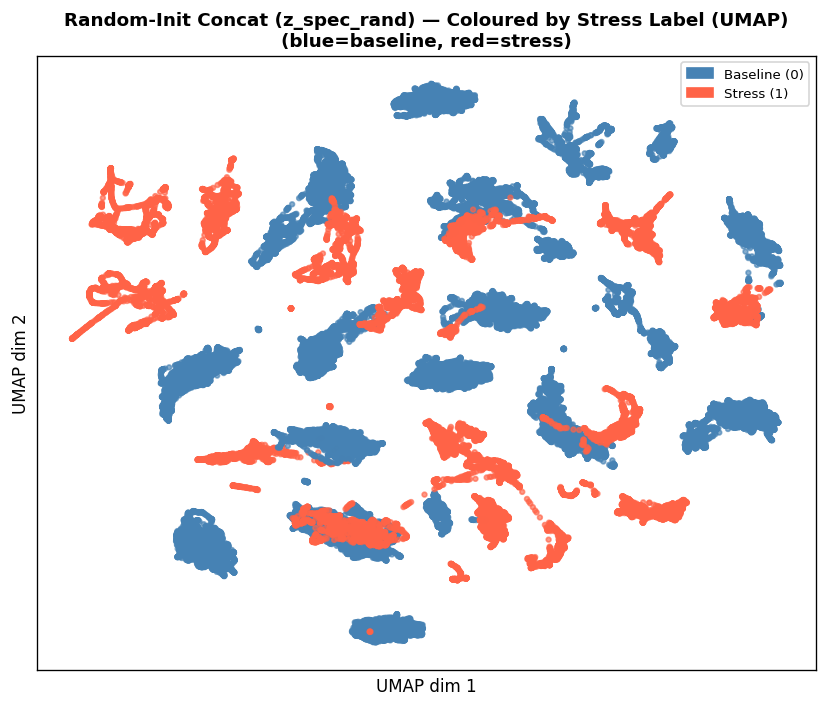

Saved → ./umap_plots/WESADModel_Random-Init_Concat_z_spec_rand_umap_stress.png


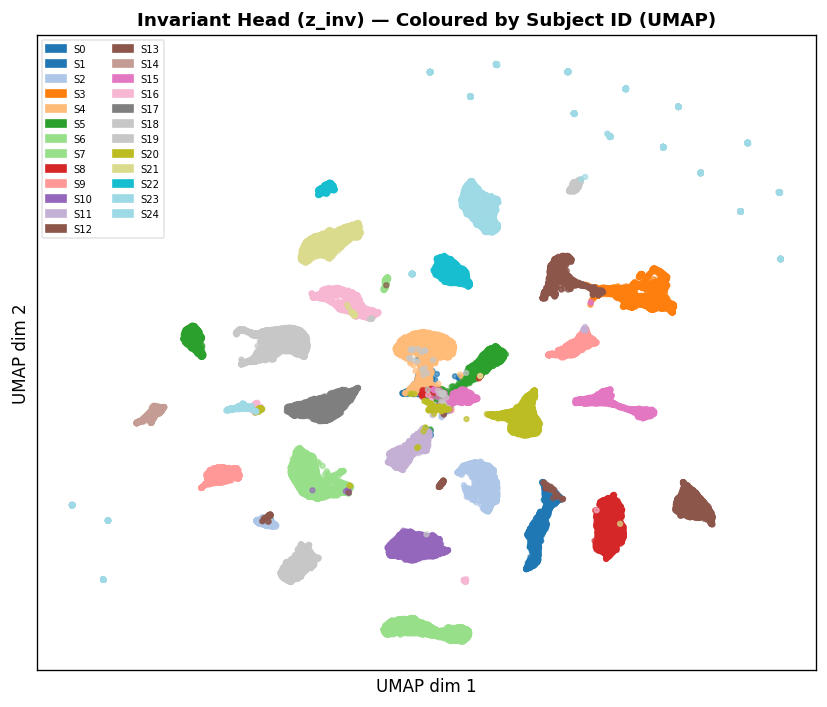

Saved → ./umap_plots/SWELLModel_Invariant_Head_z_inv_umap_subjects.png


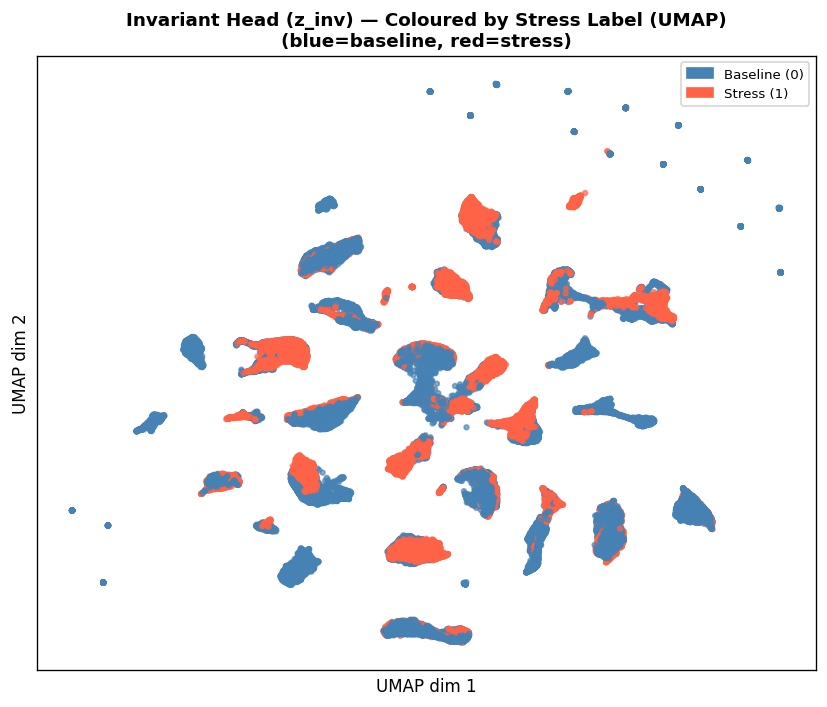

Saved → ./umap_plots/SWELLModel_Invariant_Head_z_inv_umap_stress.png


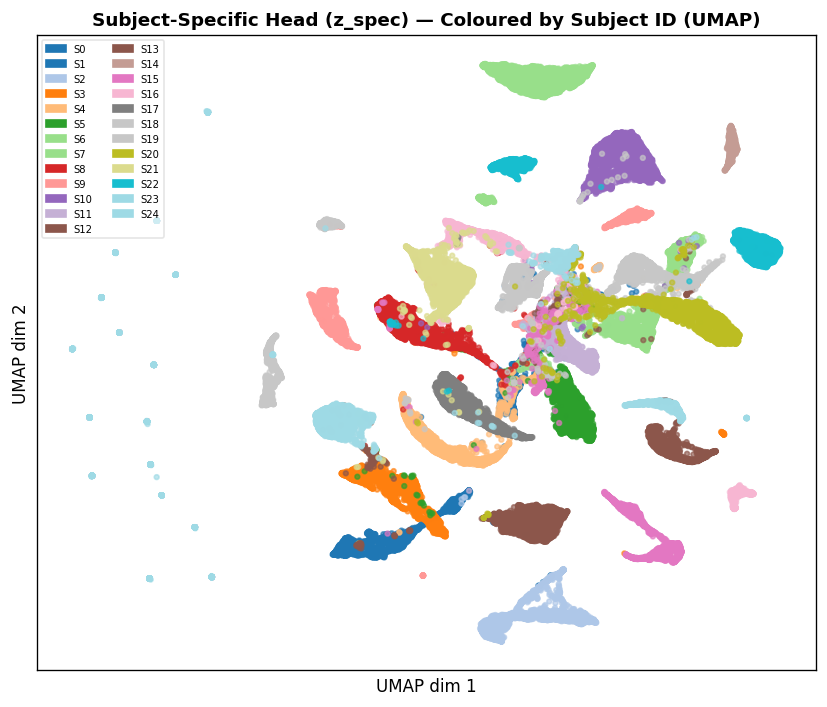

Saved → ./umap_plots/SWELLModel_Subject-Specific_Head_z_spec_umap_subjects.png


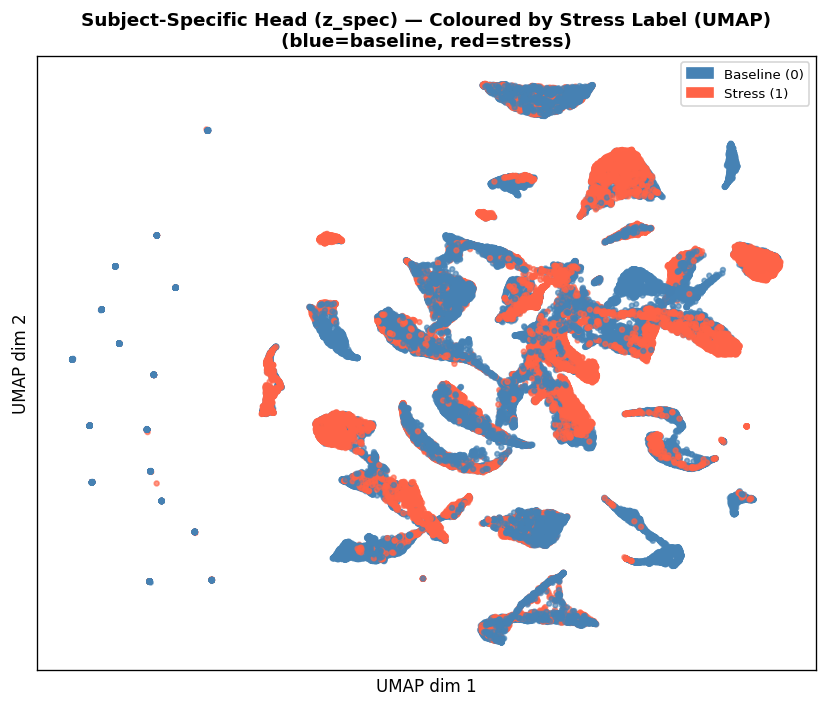

Saved → ./umap_plots/SWELLModel_Subject-Specific_Head_z_spec_umap_stress.png


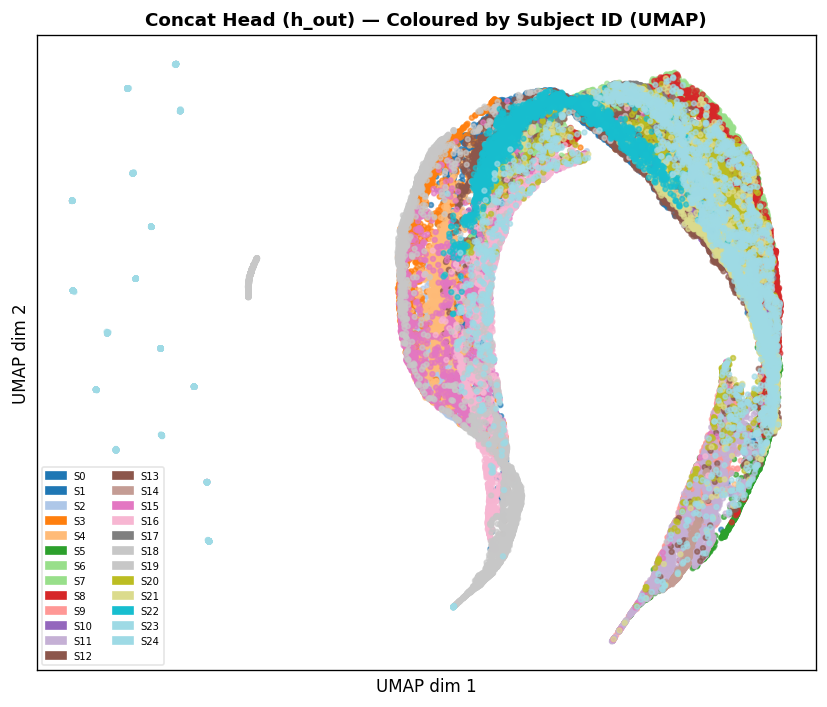

Saved → ./umap_plots/SWELLModel_Concat_Head_h_out_umap_subjects.png


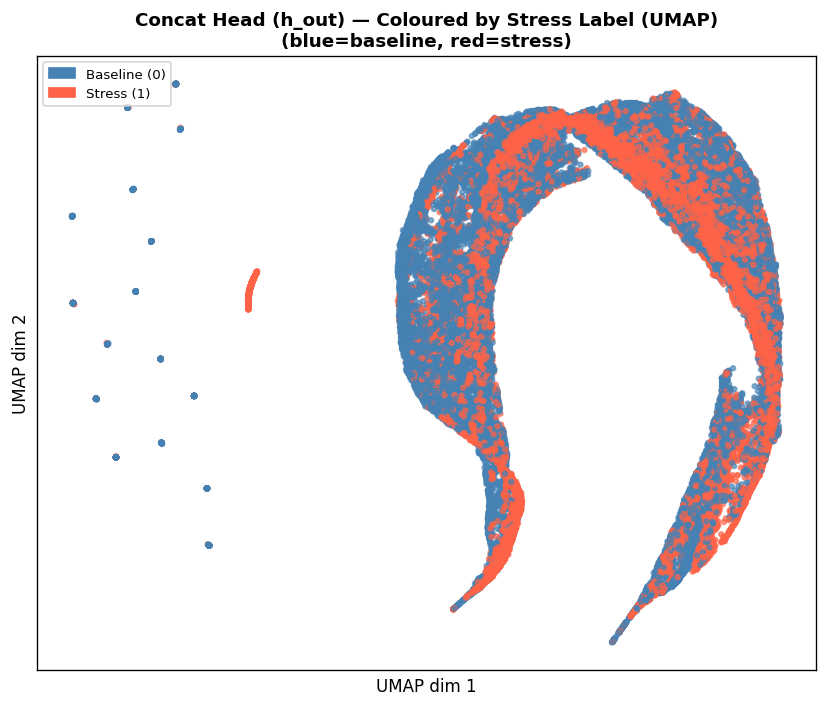

Saved → ./umap_plots/SWELLModel_Concat_Head_h_out_umap_stress.png


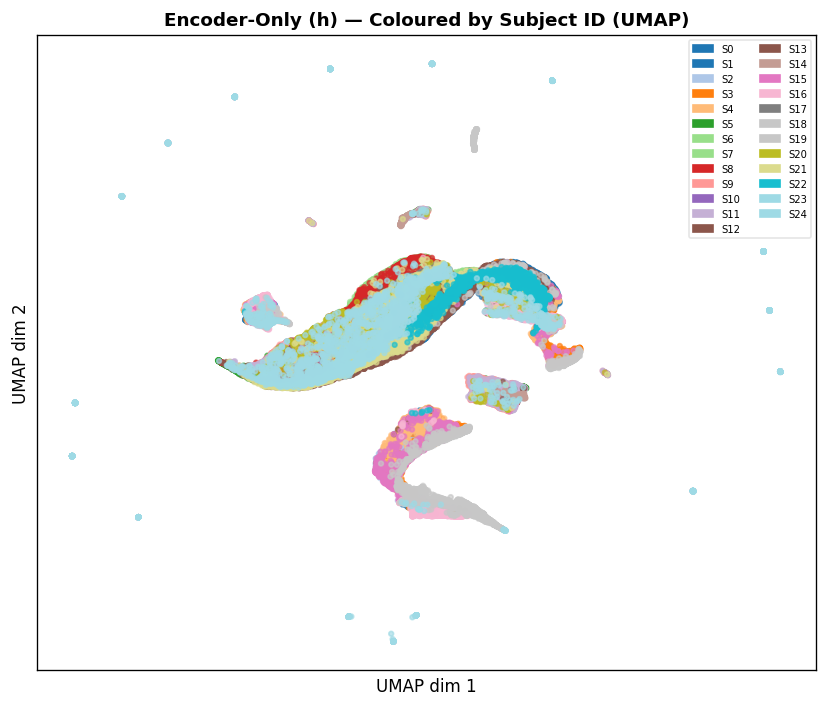

Saved → ./umap_plots/SWELLModel_Encoder-Only_h_umap_subjects.png


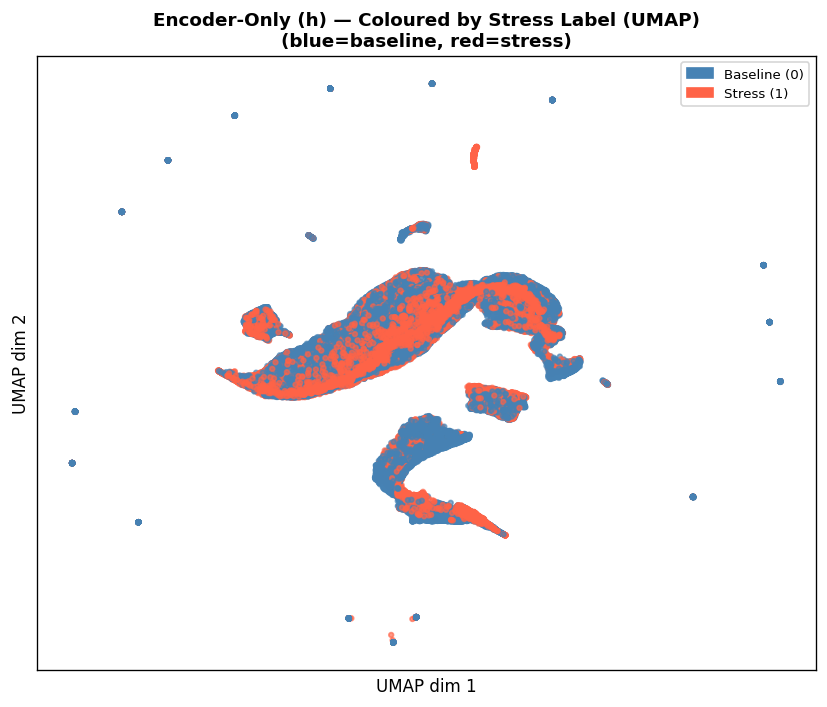

Saved → ./umap_plots/SWELLModel_Encoder-Only_h_umap_stress.png


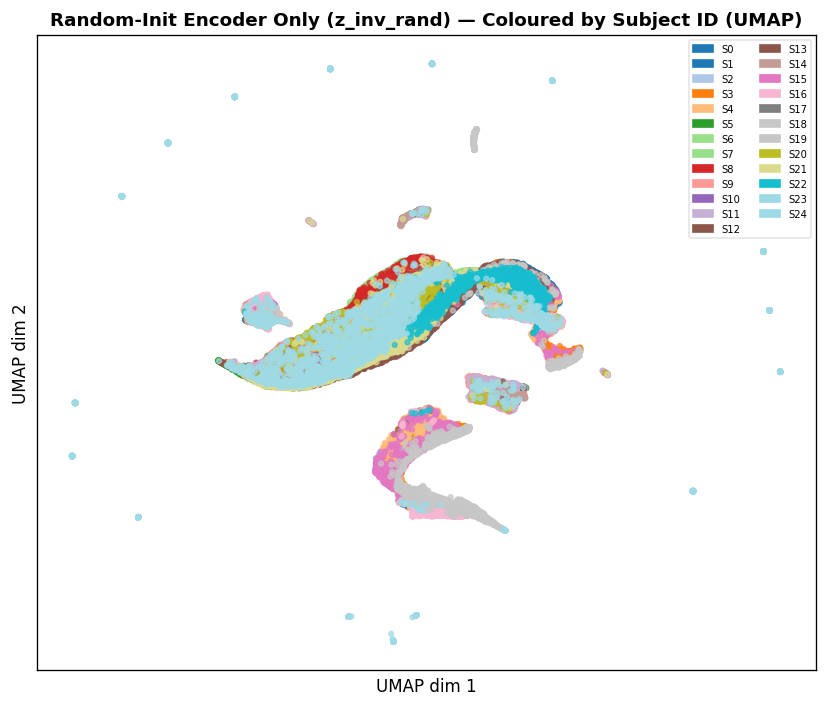

Saved → ./umap_plots/SWELLModel_Random-Init_Encoder_Only_z_inv_rand_umap_subjects.png


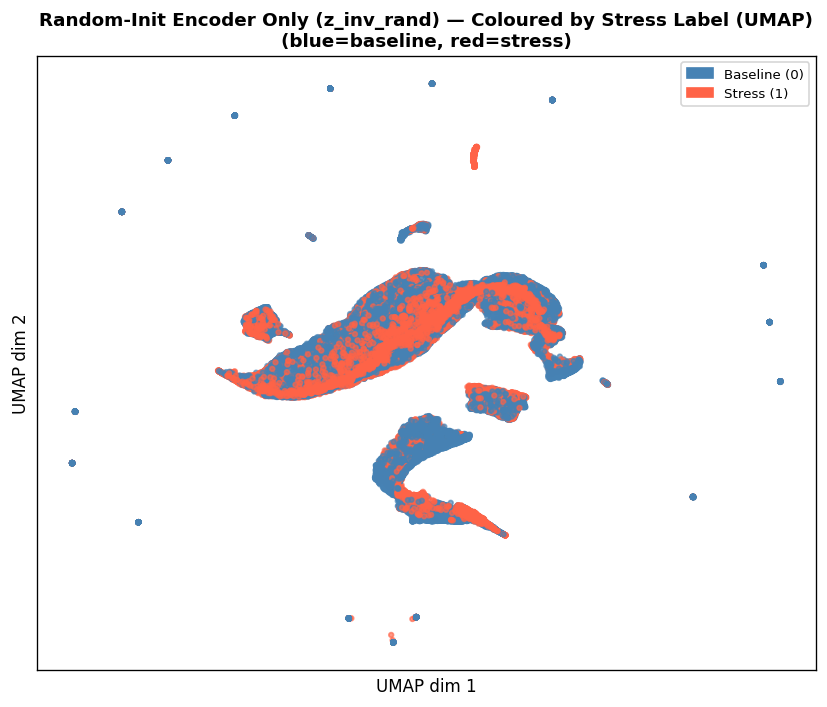

Saved → ./umap_plots/SWELLModel_Random-Init_Encoder_Only_z_inv_rand_umap_stress.png


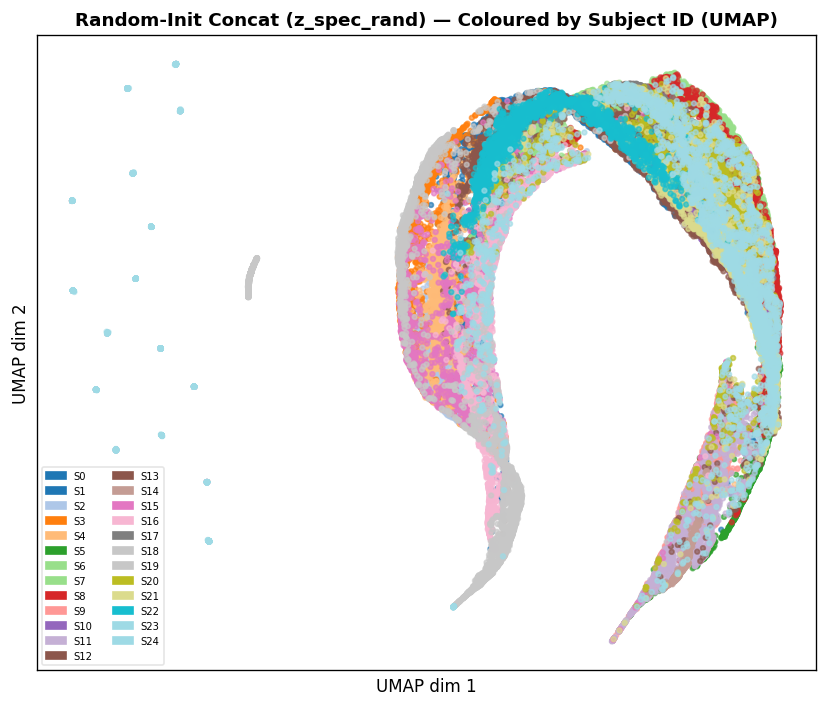

Saved → ./umap_plots/SWELLModel_Random-Init_Concat_z_spec_rand_umap_subjects.png


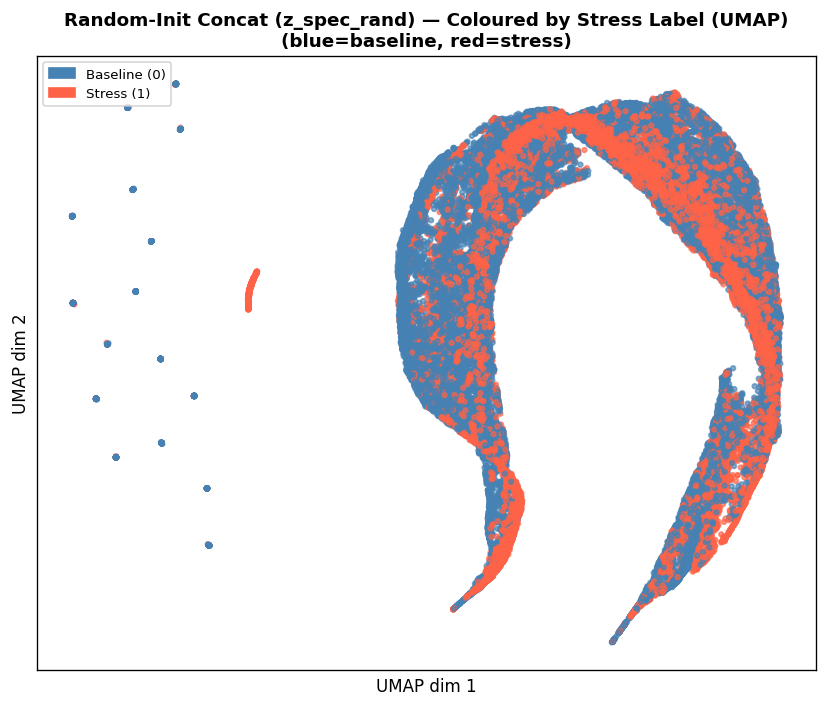

Saved → ./umap_plots/SWELLModel_Random-Init_Concat_z_spec_rand_umap_stress.png


In [17]:
# ── Collect metrics into a DataFrame ─────────────────────────────────────────
metrics_rows = []
for dataset in run_data:
    for embedding_name in run_data[dataset]:
        rd = run_data[dataset][embedding_name]
        metrics_rows.append({
            "Dataset":    dataset,
            "Embedding":  rd["label"],
            **rd["metrics"],          # Uniformity, Label_Separability, Subject_Separability
        })
 
metrics_df = pd.DataFrame(metrics_rows).set_index(["Dataset", "Embedding"])
print(metrics_df.to_string())
 
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "embedding_metrics.csv"))
 
 
# ── Plot and save individual panels ──────────────────────────────────────────
for dataset in run_data:
    for embedding_name in run_data[dataset]:
        rd  = run_data[dataset][embedding_name]
        S, L = rd["S"], rd["L"]
        lbl  = rd["label"]
        has_labels = L is not None
 
        for method in ["UMAP"]:
            XY = rd[method]
 
            # Shared file-safe prefix
            safe_lbl = (
                lbl.replace(" ", "_")
                   .replace("(", "")
                   .replace(")", "")
                   .replace("/", "_")
            )
            prefix = os.path.join(OUTPUT_DIR, f"{dataset}_{safe_lbl}_{method.lower()}")
 
            # ── Panel 1: Subject ID ───────────────────────────────────────
            fig1, ax1 = plt.subplots(figsize=(7, 6))
            colors, unique_s, cmap_s = cmap_colors(S, "tab20")
            ax1.scatter(XY[:, 0], XY[:, 1], c=colors, s=8, alpha=0.65)
            patches = [mpatches.Patch(color=cmap_s(i), label=f"S{uid}")
                       for i, uid in enumerate(unique_s)]
            ax1.legend(handles=patches, fontsize=6, ncol=2,
                       loc="best", framealpha=0.5, markerscale=1.5)
            ax1.set_title(f"{lbl} — Coloured by Subject ID ({method})",
                          fontsize=11, fontweight="bold")
            ax1.set_xticks([]); ax1.set_yticks([])
            ax1.set_xlabel(f"{method} dim 1"); ax1.set_ylabel(f"{method} dim 2")
            plt.tight_layout()
            path1 = f"{prefix}_subjects.png"
            fig1.savefig(path1, dpi=150, bbox_inches="tight")
            plt.show()
            plt.close(fig1)
            print(f"Saved → {path1}")
 
            # ── Panel 3: Stress label (only when labels exist) ────────────
            if has_labels:
                fig3, ax3 = plt.subplots(figsize=(7, 6))
                label_colors = np.where(L == 1, "tomato", "steelblue")
                ax3.scatter(XY[:, 0], XY[:, 1], c=label_colors, s=8, alpha=0.65)
                ax3.set_title(
                    f"{lbl} — Coloured by Stress Label ({method})\n"
                    "(blue=baseline, red=stress)",
                    fontsize=11, fontweight="bold",
                )
                ax3.set_xticks([]); ax3.set_yticks([])
                ax3.set_xlabel(f"{method} dim 1"); ax3.set_ylabel(f"{method} dim 2")
                patches_l = [
                    mpatches.Patch(color="steelblue", label="Baseline (0)"),
                    mpatches.Patch(color="tomato",    label="Stress (1)"),
                ]
                ax3.legend(handles=patches_l, fontsize=8, loc="best")
                plt.tight_layout()
                path3 = f"{prefix}_stress.png"
                fig3.savefig(path3, dpi=150, bbox_inches="tight")
                plt.show()
                plt.close(fig3)
                print(f"Saved → {path3}")
 

## 8. Metrics Summary Table

In [ ]:
import pandas as pd

rows = []

for dataset in run_data:
    rd = run_data[dataset]
    m = rd["metrics"]
    lbl = rd["label"]

    # flatten metrics per dataset/run
    rows.append({
        "dataset": dataset,
        "label": lbl,
        "uniformity": m.get("uniformity"),
        "alignment": m.get("alignment"),
        "label_separability": m.get("label_separability"),
        "subject_separability": m.get("subject_separability"),
    })

df_metrics = pd.DataFrame(rows)

df_metrics

,ARI,NMI,Silhouette
Head,,,
Invariant Head (z_inv),0.759,0.873,0.108
Subject-Specific Head (z_spec),0.999,0.999,0.773
Concat Head (h_out),0.755,0.879,0.117


Saved → ./umap_plots/kmeans_metrics.csv
